In [1]:
%pip install pandas numpy xgboost scikit-learn matplotlib seaborn inline

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for inline: filename=inline-0.0.1-py3-none-any.whl size=3383 sha256=57ca0dac48a17b6d58dcc920c7a6046ba11045b019ddee96c0e777aa943976f0
  Stored in directory: /home/desarrolloab/.cache/pip/wheels/b3/77/1d/942e15841ad6de1a6a1937dadff4e5df540cb7a0e1f0dcdea4
Successfully built inline
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os

In [3]:
sys.path.append(os.path.abspath('..'))

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing as dp

In [5]:
df = pd.read_csv('../data/raw/results.csv')
df_ranking = pd.read_csv('../data/raw/fifa_ranking.csv')
df_world_cup = pd.read_csv('../data/raw/fifa_world_cup.csv')
df_world_cup_matches = pd.read_csv('../data/raw/world_cup.csv')



In [6]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [7]:
df_ranking.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [8]:
df_world_cup_matches.head()

,year,date,stage,home_team,away_team,home_goals,away_goals,winner,match_id
0,1974,1974-06-10,Quarter-finals,South Korea,Sweden,0,0,Draw,1
1,1974,1974-06-10,Quarter-finals,Ghana,Switzerland,2,0,Ghana,2
2,1974,1974-06-10,Group Stage,Sweden,Saudi Arabia,2,0,Sweden,3
3,1974,1974-06-10,Group Stage,Cameroon,Uruguay,2,1,Cameroon,4
4,1974,1974-06-10,Group Stage,Nigeria,Japan,2,1,Nigeria,5


In [9]:
df_world_cup.head()

,id,edition,year,host_country,host_continent,winner,second_place,third_place,fourth_place,total_teams
0,WC-1930,1,1930,Uruguay,South America,Uruguay,Argentina,United States,Yugoslavia,13
1,WC-1934,2,1934,Italy,Europe,Italy,Czechoslovakia,Germany,Austria,16
2,WC-1938,3,1938,France,Europe,Italy,Hungary,Brazil,Sweden,15
3,WC-1950,4,1950,Brazil,South America,Uruguay,Brazil,Sweden,Spain,13
4,WC-1954,5,1954,Switzerland,Europe,West Germany,Hungary,Austria,Uruguay,16


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49329 entries, 0 to 49328
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49329 non-null  str    
 1   home_team   49329 non-null  str    
 2   away_team   49329 non-null  str    
 3   home_score  49257 non-null  float64
 4   away_score  49257 non-null  float64
 5   tournament  49329 non-null  str    
 6   city        49329 non-null  str    
 7   country     49329 non-null  str    
 8   neutral     49329 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [11]:
df_ranking.info()

<class 'pandas.DataFrame'>
RangeIndex: 67472 entries, 0 to 67471
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             67463 non-null  float64
 1   country_full     67472 non-null  str    
 2   country_abrv     67472 non-null  str    
 3   total_points     67472 non-null  float64
 4   previous_points  67472 non-null  float64
 5   rank_change      67472 non-null  int64  
 6   confederation    67472 non-null  str    
 7   rank_date        67472 non-null  str    
dtypes: float64(3), int64(1), str(4)
memory usage: 4.1 MB


In [12]:
df_world_cup.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              22 non-null     str  
 1   edition         22 non-null     int64
 2   year            22 non-null     int64
 3   host_country    22 non-null     str  
 4   host_continent  22 non-null     str  
 5   winner          22 non-null     str  
 6   second_place    22 non-null     str  
 7   third_place     22 non-null     str  
 8   fourth_place    22 non-null     str  
 9   total_teams     22 non-null     int64
dtypes: int64(3), str(7)
memory usage: 1.8 KB


In [13]:
df_world_cup_matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        832 non-null    int64
 1   date        832 non-null    str  
 2   stage       832 non-null    str  
 3   home_team   832 non-null    str  
 4   away_team   832 non-null    str  
 5   home_goals  832 non-null    int64
 6   away_goals  832 non-null    int64
 7   winner      832 non-null    str  
 8   match_id    832 non-null    int64
dtypes: int64(4), str(5)
memory usage: 58.6 KB


In [14]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')

## Importancia de la columna `neutral`

La columna `neutral` es crucial para el análisis de resultados de fútbol porque:

- **Detecta la ventaja de localía**: Indica si el partido se jugó en territorio neutral o en casa del equipo local.
- **Impacto en el rendimiento**: La localía tiene una influencia significativa en el resultado del partido.

### Ejemplo

Brasil jugando en Brasil ≠ Brasil jugando en Qatar

Un equipo tiene ventajas considerables cuando juega en su propio territorio (factor de localía), mientras que en campos neutrales las condiciones son más equitativas para ambos equipos.

In [15]:
df_world_cup.columns

Index(['id', 'edition', 'year', 'host_country', 'host_continent', 'winner',
       'second_place', 'third_place', 'fourth_place', 'total_teams'],
      dtype='str')

In [16]:
df_ranking.columns

Index(['rank', 'country_full', 'country_abrv', 'total_points',
       'previous_points', 'rank_change', 'confederation', 'rank_date'],
      dtype='str')

In [17]:
df_world_cup.columns

Index(['id', 'edition', 'year', 'host_country', 'host_continent', 'winner',
       'second_place', 'third_place', 'fourth_place', 'total_teams'],
      dtype='str')

In [18]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [19]:
df_ranking.isnull().sum()

rank               9
country_full       0
country_abrv       0
total_points       0
previous_points    0
rank_change        0
confederation      0
rank_date          0
dtype: int64

In [20]:
df_world_cup.isnull().sum()

id                0
edition           0
year              0
host_country      0
host_continent    0
winner            0
second_place      0
third_place       0
fourth_place      0
total_teams       0
dtype: int64

In [21]:
df_world_cup_matches.isnull().sum()

year          0
date          0
stage         0
home_team     0
away_team     0
home_goals    0
away_goals    0
winner        0
match_id      0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
# Eliminamos las filas con valores nulos en las columnas 'home_score' y 'away_score'
df = df.dropna(subset=['home_score', 'away_score'])

In [24]:
df_ranking = df_ranking.dropna(subset=['rank'])

In [25]:
df.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [26]:
df_ranking.isnull().sum() 

rank               0
country_full       0
country_abrv       0
total_points       0
previous_points    0
rank_change        0
confederation      0
rank_date          0
dtype: int64

In [27]:
# Muestra el número de filas y columnas en el DataFrame
df.shape

(49257, 9)

In [28]:
df_ranking.shape

(67463, 8)

In [29]:
df_world_cup.shape

(22, 10)

In [30]:
df_world_cup_matches.shape

(832, 9)

In [31]:
df_master = dp.load_and_clean_matches(
    matches_path='../data/raw/results.csv',
    ranking_path='../data/raw/fifa_ranking.csv'
)

In [32]:
df_world_cup = pd.read_csv('../data/raw/fifa_world_cup.csv')
df_world_cup_matches = pd.read_csv('../data/raw/world_cup.csv')

In [33]:
df_master.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,rank_home,rank_away,result
0,1998-01-03,Malawi,Zimbabwe,1.0,0.0,Friendly,Blantyre,Malawi,False,97.0,74.0,2
1,1998-01-04,Barbados,Trinidad and Tobago,0.0,1.0,Friendly,Bridgetown,Barbados,False,113.0,56.0,0
2,1998-01-04,Burkina Faso,Mozambique,1.0,0.0,Friendly,Bobo Dioulasso,Burkina Faso,False,106.0,67.0,2
3,1998-01-04,Guinea,Togo,1.0,0.0,Friendly,Conakry,Guinea,False,65.0,78.0,2
4,1998-01-04,Malawi,Zimbabwe,0.0,2.0,Friendly,Lilongwe,Malawi,False,97.0,74.0,0


In [34]:
df_master['rank_diff'] = df_master['rank_home'] - df_master['rank_away']

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

/tmp/ipykernel_14720/3500677094.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='result', y='rank_diff', data=df_master, palette='viridis')


<Axes: xlabel='result', ylabel='rank_diff'>

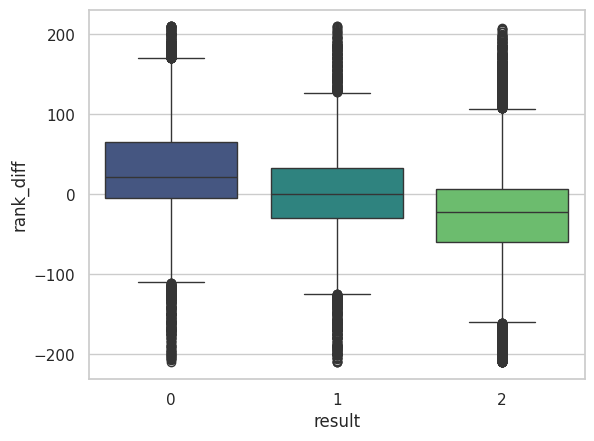

In [36]:
sns.boxplot(x='result', y='rank_diff', data=df_master, palette='viridis')

In [37]:
print("Filas y columnas:", df_master.shape)

# 2. Verificamos que las columnas necesarias existan
print("\nColumnas disponibles:", df_master.columns.tolist())

# 3. Verificamos el TIPO de dato (Deben ser int o float, NO object)
print("\nTipos de datos de los rankings:")
print(df_master[['rank_home', 'rank_away']].dtypes)

Filas y columnas: (26733, 13)

Columnas disponibles: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'rank_home', 'rank_away', 'result', 'rank_diff']

Tipos de datos de los rankings:
rank_home    float64
rank_away    float64
dtype: object


In [38]:
plt.clf()
plt.close('all')

/tmp/ipykernel_14720/3430104669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='result', y='rank_diff', data=df_master, palette='viridis')


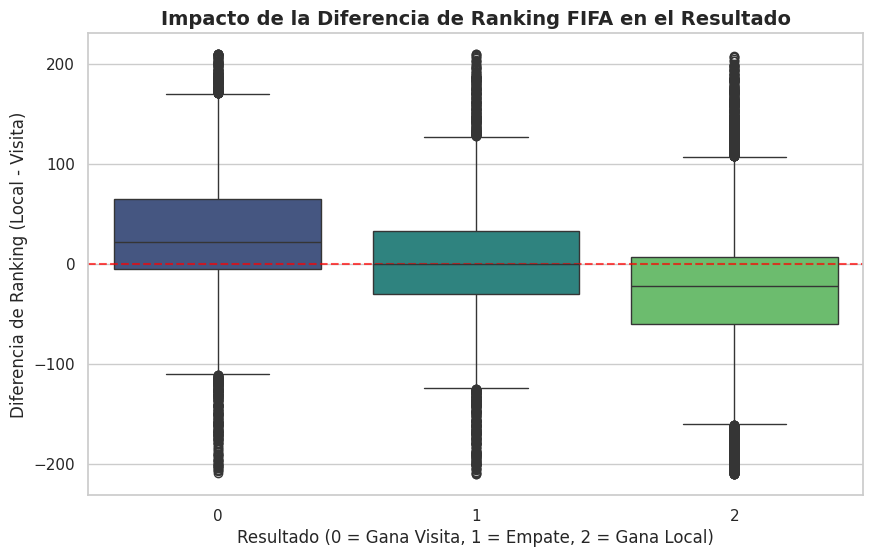

In [39]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(x='result', y='rank_diff', data=df_master, palette='viridis')

plt.title('Impacto de la Diferencia de Ranking FIFA en el Resultado', fontsize=14, fontweight='bold')
plt.xlabel('Resultado (0 = Gana Visita, 1 = Empate, 2 = Gana Local)', fontsize=12)
plt.ylabel('Diferencia de Ranking (Local - Visita)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.7)

In [40]:
plt.show()